# Shape Feature Correlation

In [24]:
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import os

In [25]:
# Load dataset path
dataset_path = "crab-images-dataset/test"

In [26]:
# Dataset Preparation: Loop through images in each species folder and compute contours, hu moments, 
# area, perimeter, and circularity (target shape features) stored in data[] for dataframe
data = []

for species in os.listdir(dataset_path):
    species_path = os.path.join(dataset_path, species)
    
    if not os.path.isdir(species_path):  
        continue # Skip
        
    for img_name in os.listdir(species_path):
        img_path = os.path.join(species_path, img_name)

        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            print(f"Skipping {img_name} in {species}, image could not be read.")
            continue  # Skip invalid images

        _, thresh = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY_INV)
        if np.count_nonzero(thresh) == 0:
            print(f"Skipping {img_name} in {species}, blank image after thresholding.")
            continue  # Skip

        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(contours) > 0:
            cnt = max(contours, key=cv2.contourArea)
            hu_moments = cv2.HuMoments(cv2.moments(cnt)).flatten()[:5]  # Keep only Hu_0 - Hu_4
            area = cv2.contourArea(cnt)
            perimeter = cv2.arcLength(cnt, True)
            circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0

            data.append([species, img_name] + list(hu_moments) + [area, perimeter, circularity])

In [27]:
# Convert to dataframe
columns = ["Species", "Image_Name"] + [f"Hu_{i}" for i in range(5)] + ["Area", "Perimeter", "Circularity"]
df = pd.DataFrame(data, columns=columns)

# Display the first few rows
print(df.head())

          Species        Image_Name      Hu_0      Hu_1      Hu_2      Hu_3  \
0  dungeness_crab  1G4CRUSWGXLH.jpg  0.249652  0.015279  0.001256  0.000147   
1  dungeness_crab  1KTGVYDIR2EV.jpg  0.208581  0.000175  0.000034  0.000093   
2  dungeness_crab  2EEHIQIUHJPG.jpg  0.183342  0.000298  0.000055  0.000001   
3  dungeness_crab  2XRSL6MDF0W8.jpg  0.263146  0.015595  0.006969  0.001776   
4  dungeness_crab  38G1R3YFM7DA.jpg  0.533746  0.120294  0.005685  0.001056   

           Hu_4     Area    Perimeter  Circularity  
0 -1.475972e-08  23743.5  2418.500771     0.051011  
1 -3.235832e-10  52327.5  5484.978368     0.021857  
2  1.151264e-11  57319.5  2110.981878     0.161638  
3  5.668557e-06   8572.5  1421.006262     0.053349  
4  1.467283e-06  15842.0  3708.099960     0.014478  


In [28]:
# Select only numerical columns for normalization
features = ["Hu_0", "Hu_1", "Hu_2", "Hu_3", "Hu_4", "Area", "Perimeter", "Circularity"]
scaler = MinMaxScaler()

df[features] = scaler.fit_transform(df[features])

print(df.head())

          Species        Image_Name      Hu_0      Hu_1      Hu_2      Hu_3  \
0  dungeness_crab  1G4CRUSWGXLH.jpg  0.083210  0.010992  0.000851  0.000159   
1  dungeness_crab  1KTGVYDIR2EV.jpg  0.043592  0.000126  0.000023  0.000100   
2  dungeness_crab  2EEHIQIUHJPG.jpg  0.019244  0.000214  0.000037  0.000001   
3  dungeness_crab  2XRSL6MDF0W8.jpg  0.096227  0.011219  0.004722  0.001921   
4  dungeness_crab  38G1R3YFM7DA.jpg  0.357259  0.086544  0.003852  0.001142   

       Hu_4      Area  Perimeter  Circularity  
0  0.000308  0.359122   0.310642     0.055332  
1  0.000308  0.802877   0.727443     0.019968  
2  0.000308  0.880375   0.268843     0.189524  
3  0.000313  0.123599   0.175061     0.058168  
4  0.000309  0.236455   0.485927     0.011018  


In [31]:
# Select two species for shape feature comparison
def cmpr_shape_feature_species(target, cmpr_species):

    species_to_compare = [target, cmpr_species]
    df_filtered = df[df["Species"].isin(species_to_compare)]
    
    # Compute mean values for each species
    df_mean = df_filtered.groupby("Species").mean(numeric_only=True).reset_index()
    
    # Plot Bar Charts for Shape Features
    features = ["Hu_0", "Hu_1", "Hu_2", "Hu_3", "Hu_4", "Area", "Perimeter", "Circularity"]
    df_melted = df_mean.melt(id_vars=["Species"], value_vars=features, var_name="Feature", value_name="Value")
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_melted, x="Feature", y="Value", hue="Species", palette="Set2")
    plt.xticks(rotation=45)
    plt.title(f"Shape Feature Comparison: {target} vs {cmpr_species}")
    plt.legend(title="Species")
    
    # Save the figure
    filename = f"plot_{target}_vs_{cmpr_species}.png"
    plt.savefig(filename)
    plt.show()

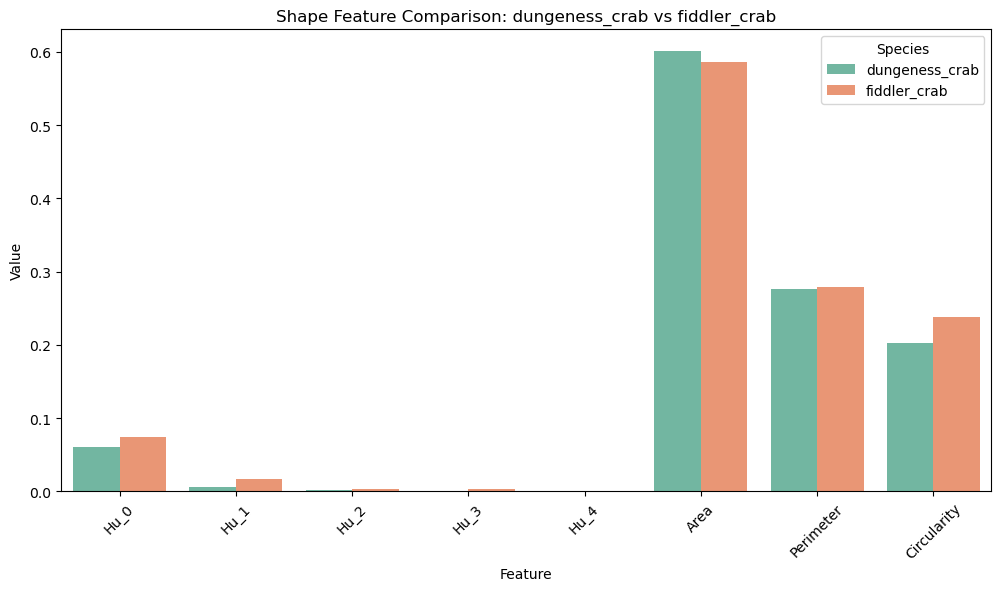

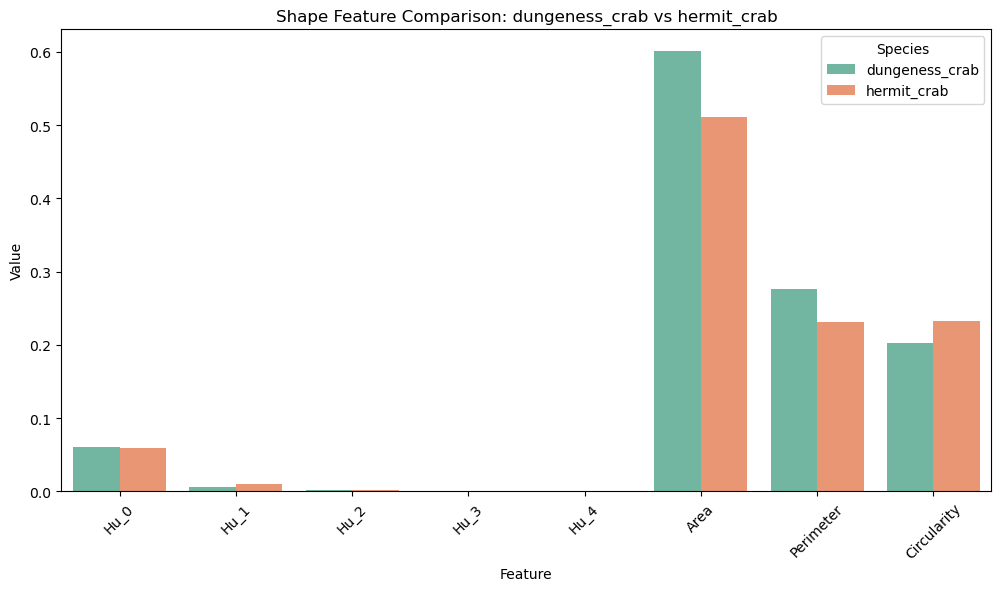

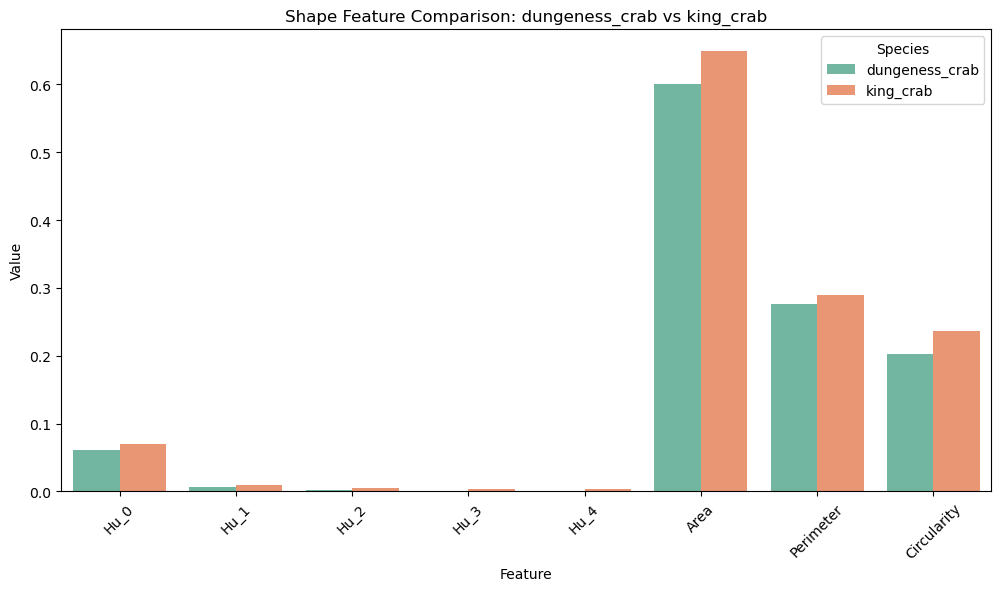

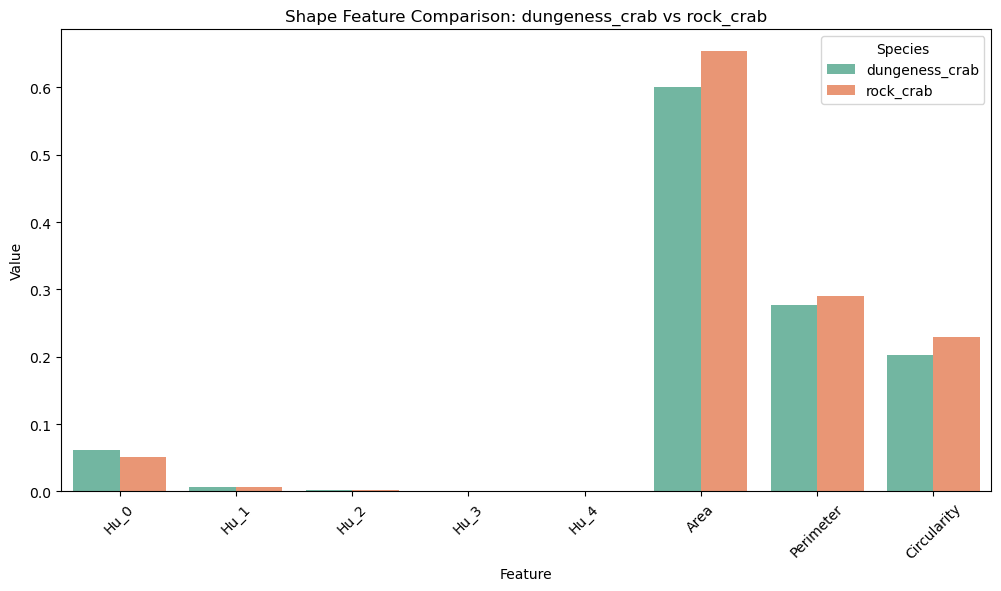

In [32]:
# Compare Dungeness Crab to other species
target = "dungeness_crab"
species_list = ["fiddler_crab", "hermit_crab", "king_crab", "rock_crab"]

for species in species_list:
    cmpr_shape_feature_species(target, species)

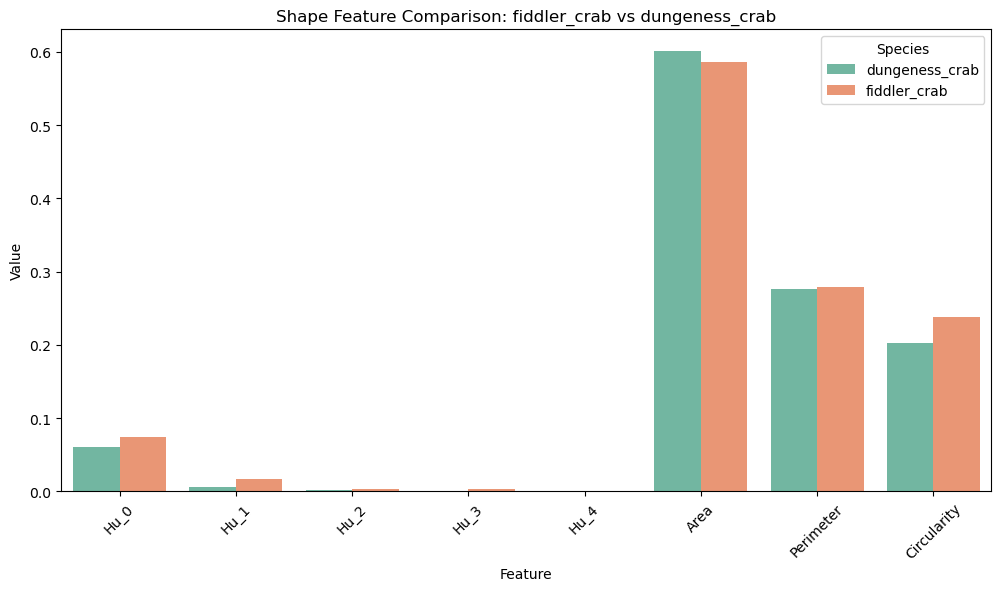

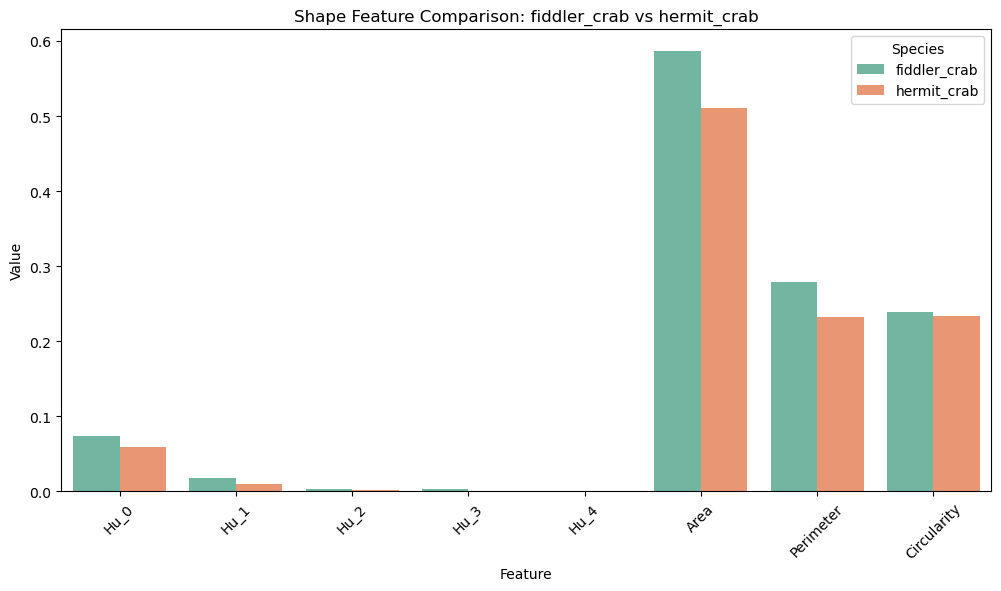

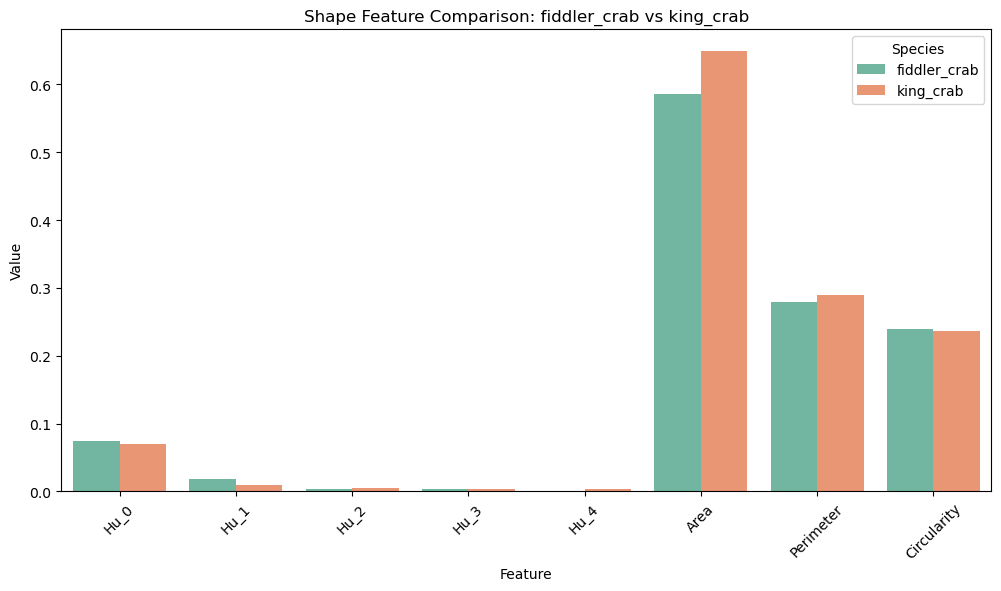

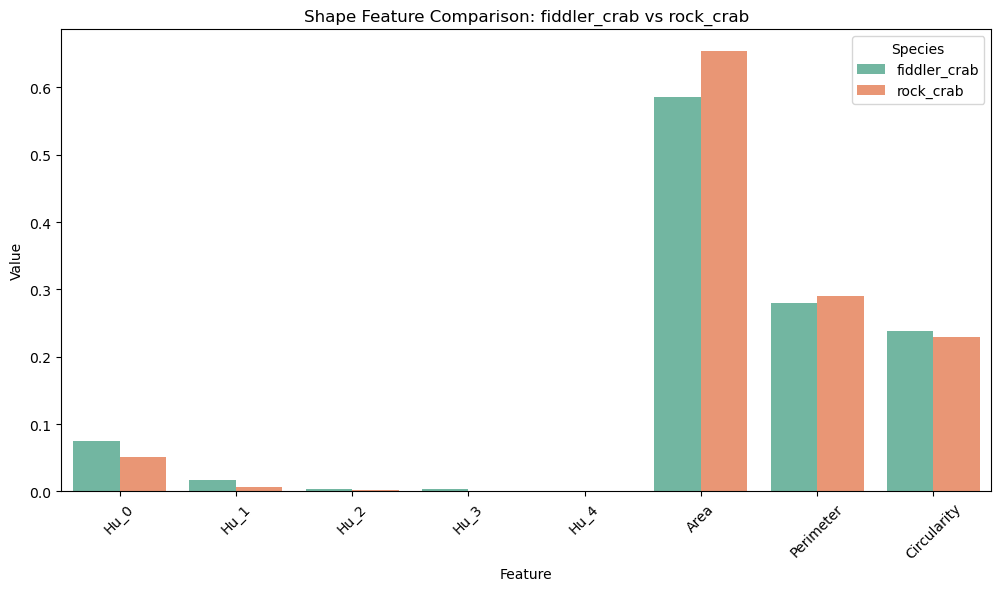

In [33]:
# Compare Fiddler Crab to other species
target =  "fiddler_crab"
species_list = ["dungeness_crab", "hermit_crab", "king_crab", "rock_crab"]

for species in species_list:
    cmpr_shape_feature_species(target, species)

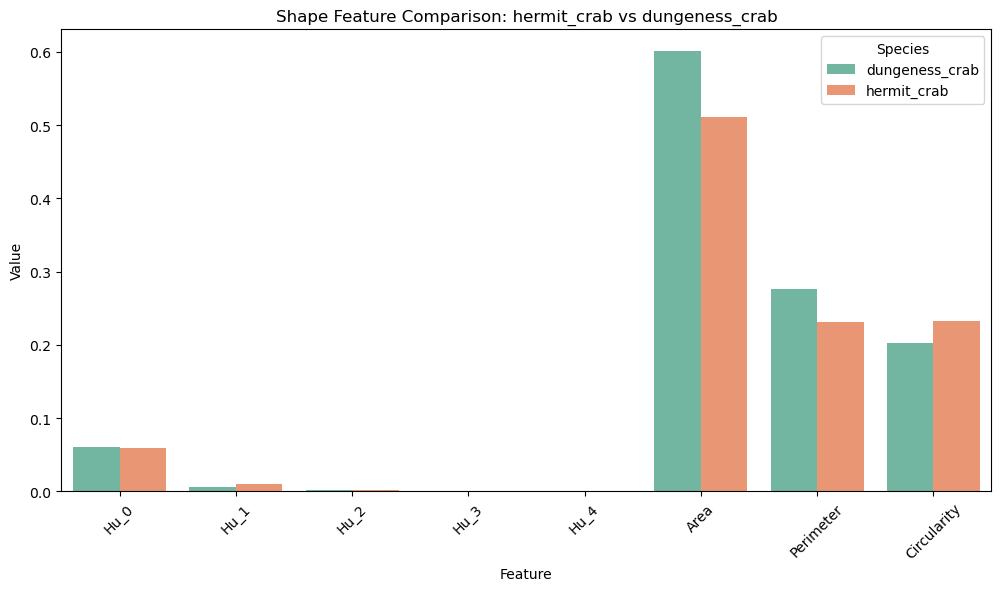

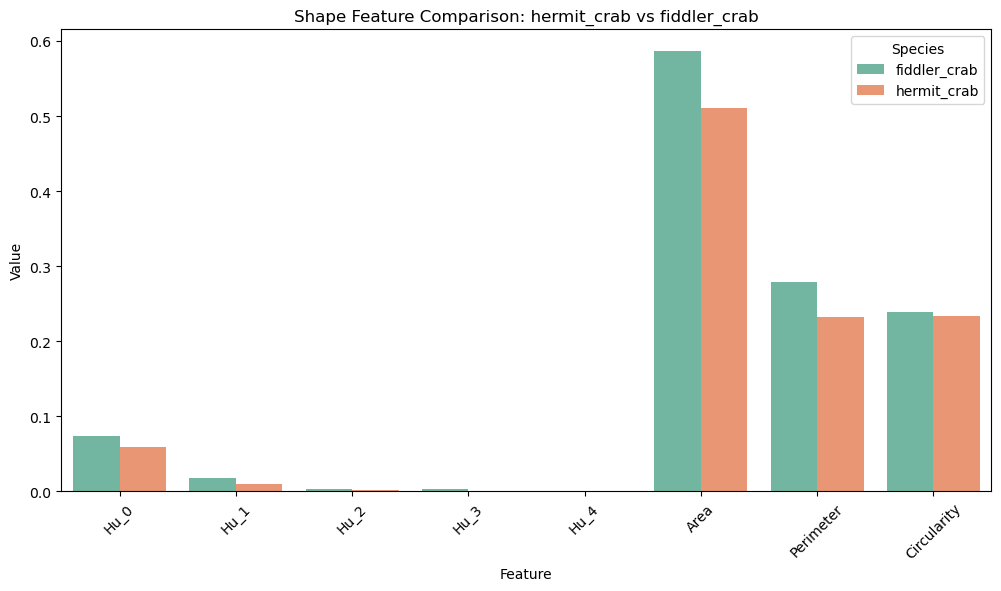

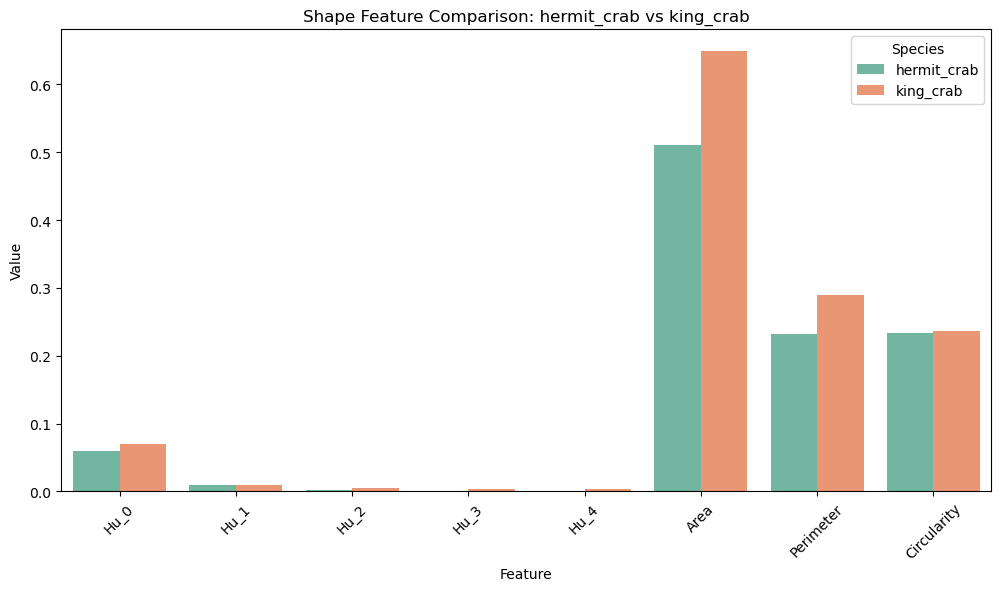

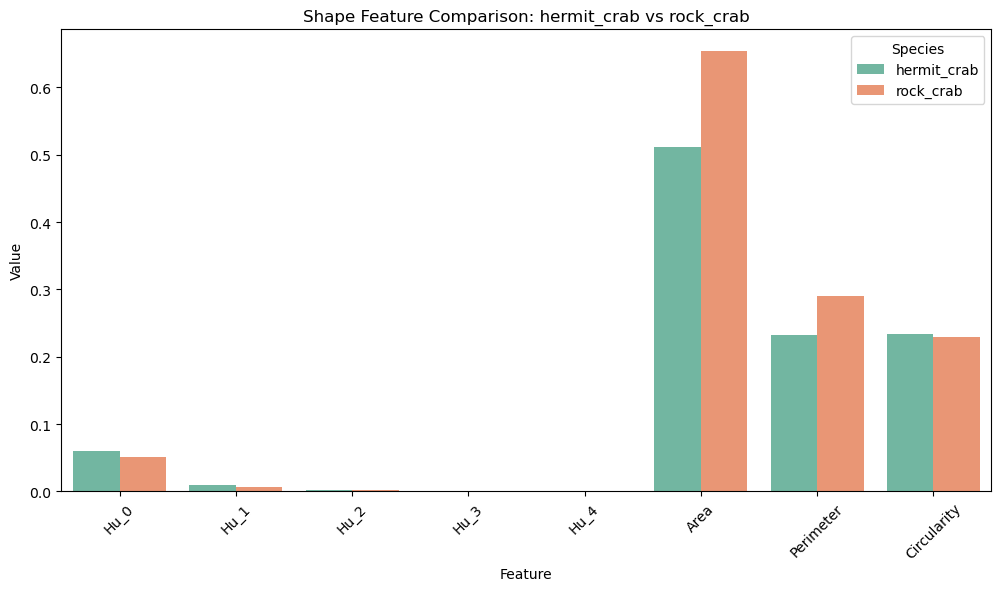

In [34]:
# Compare Hermit Crab to other species
target =  "hermit_crab"
species_list = ["dungeness_crab", "fiddler_crab", "king_crab", "rock_crab"]

for species in species_list:
    cmpr_shape_feature_species(target, species)

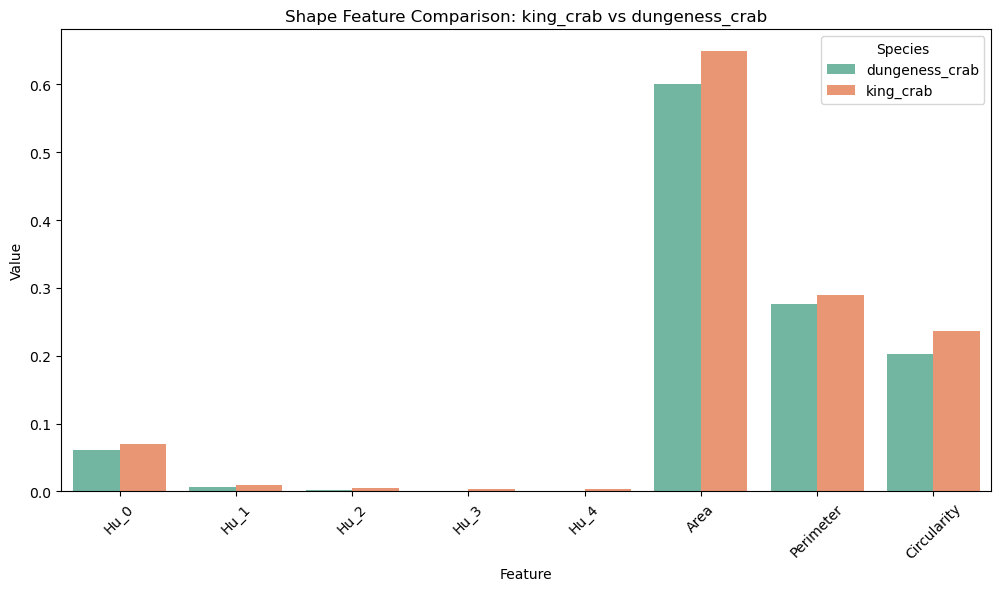

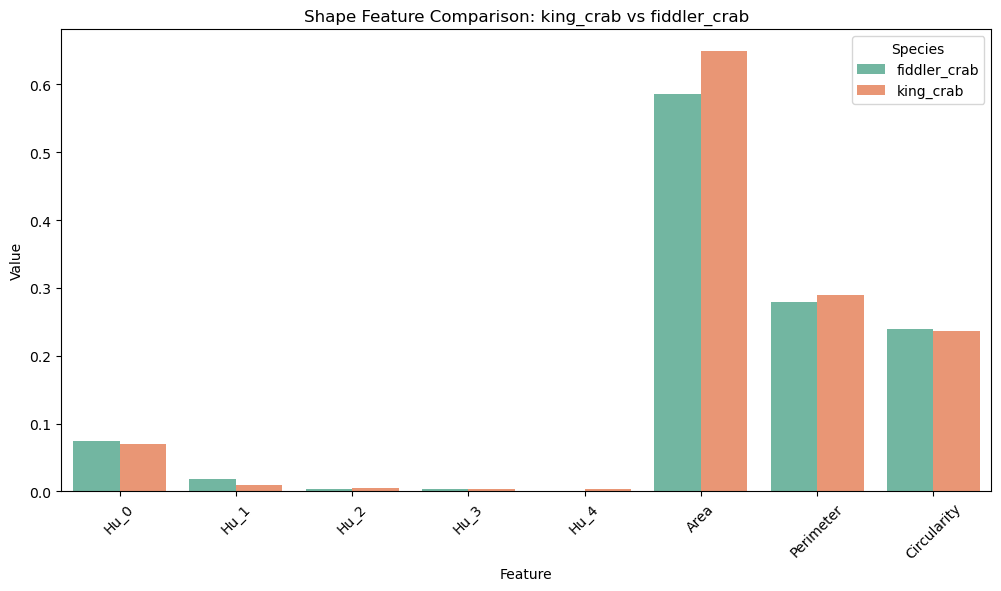

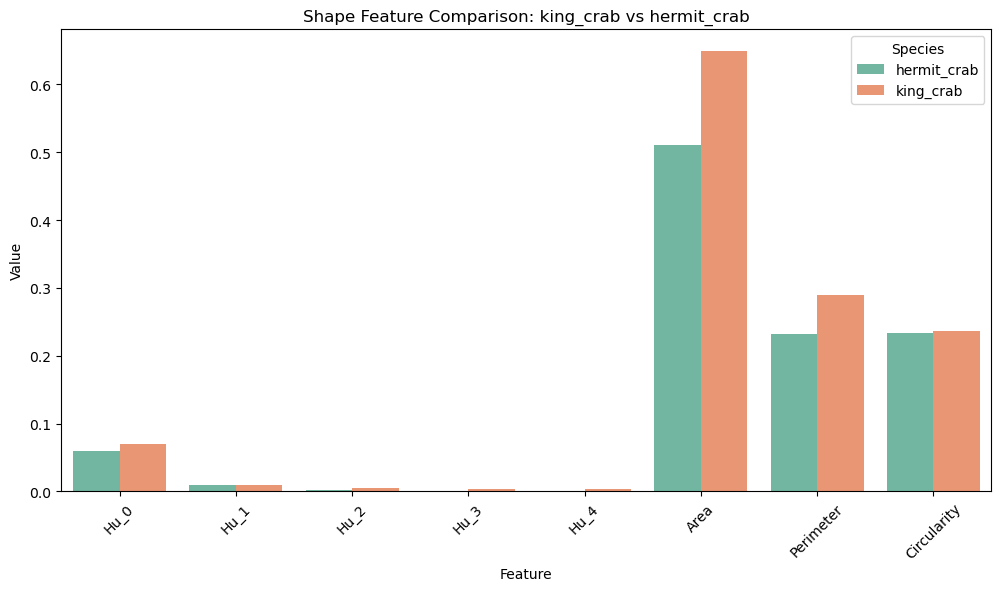

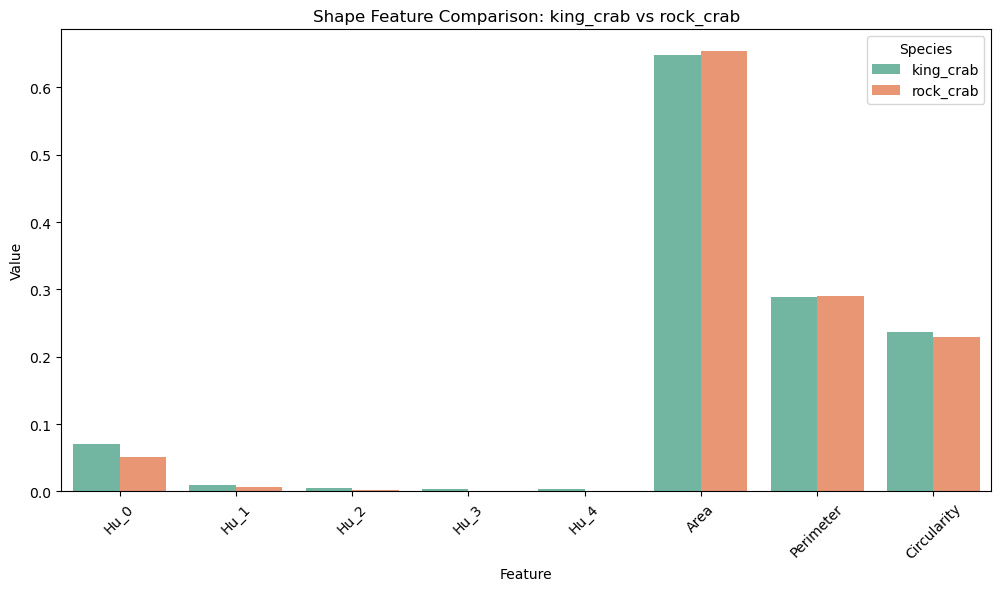

In [35]:
# Compare King Crab to other species
target =  "king_crab"
species_list = ["dungeness_crab", "fiddler_crab", "hermit_crab", "rock_crab"]

for species in species_list:
    cmpr_shape_feature_species(target, species)

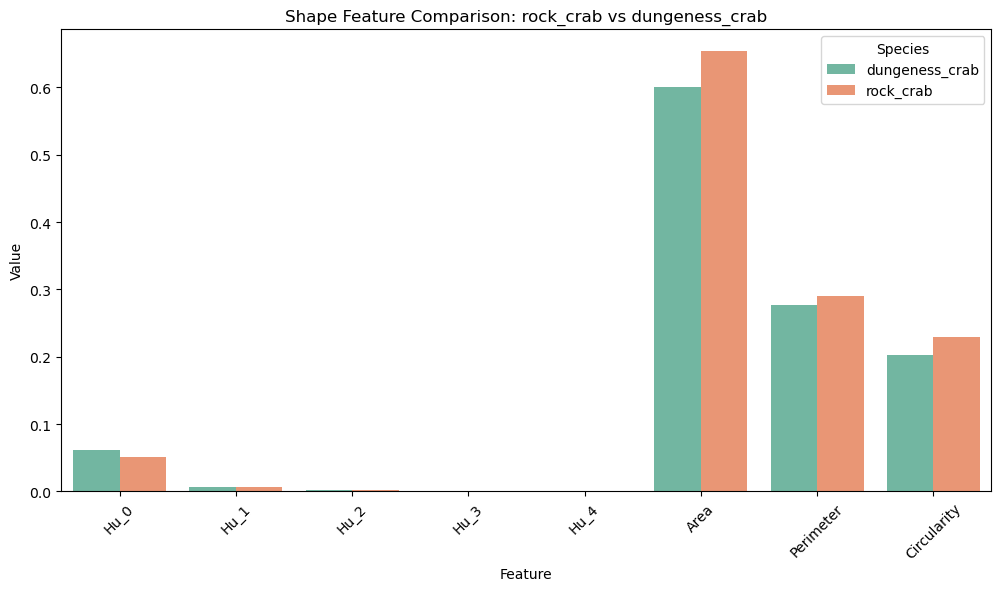

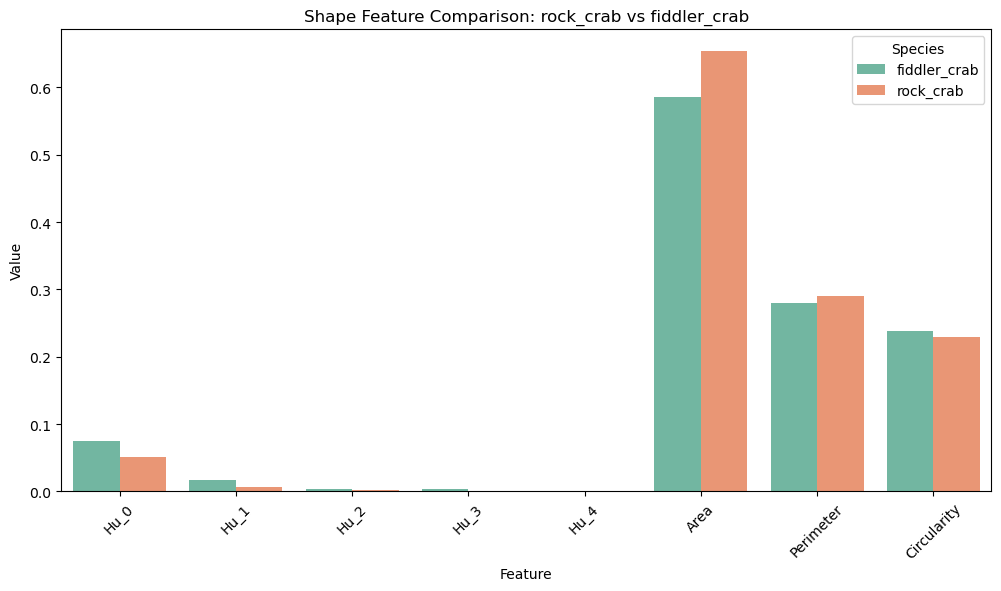

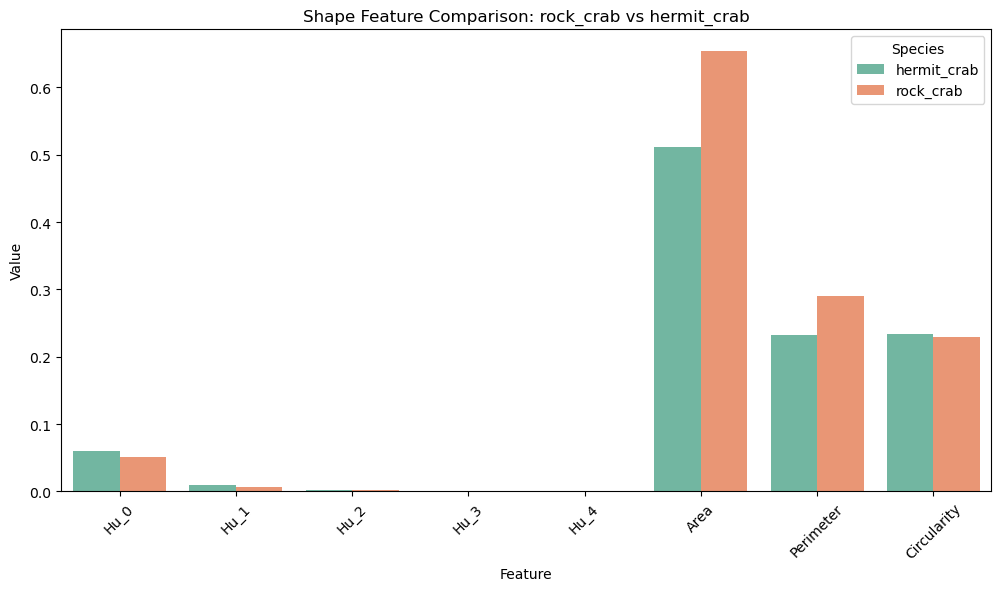

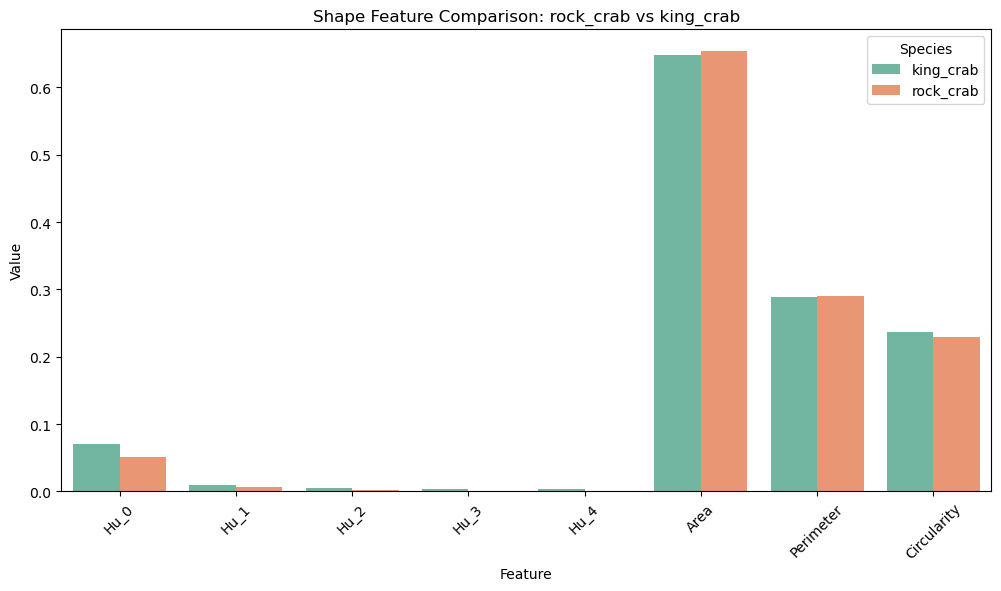

In [36]:
# Compare Rock Crab to other species
target =  "rock_crab"
species_list = ["dungeness_crab", "fiddler_crab", "hermit_crab", "king_crab"]

for species in species_list:
    cmpr_shape_feature_species(target, species)

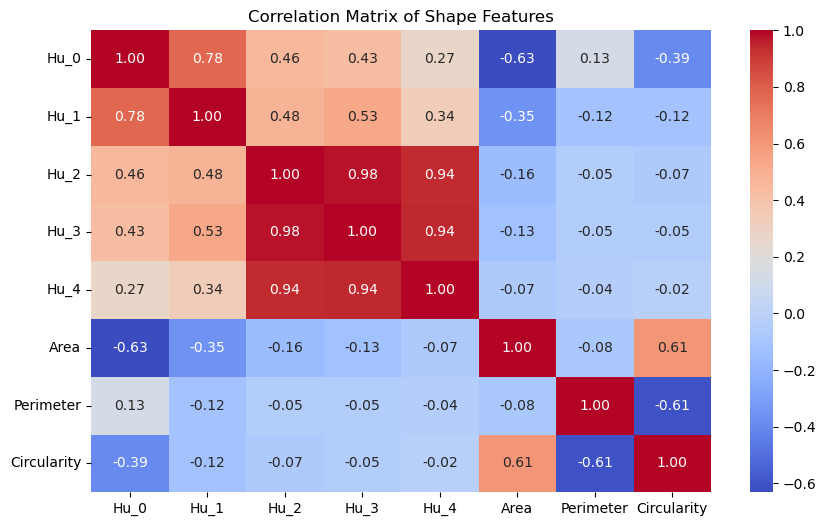

In [37]:
# Display shape feature correlation matrix
corr_matrix = df.drop(columns=["Species", "Image_Name"]).corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Shape Features")

# Save the figure
plt.savefig("plot_shape_feature_heatmap.png")
plt.show()